# 05. Fair AI Development

## 📚 Learning Objectives

By completing this notebook, you will:
- Integrate fairness into the ML lifecycle
- Use fairness-aware development practices
- Document and communicate fairness decisions

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

---

# 05. Fair AI Development

## 🚨 THE PROBLEM: We Need Systematic Fair AI Development

**Remember the limitation from the previous notebook?**

We learned how to ensure fair representation using PCA, autoencoders, and adversarial techniques. But we discovered:

**How do we apply all these techniques to build fair AI systems from the start?**

**The Problem**: We have many fairness techniques, but we need:
- ❌ **Systematic approach** from data collection to deployment
- ❌ **Best practices** for fair AI development
- ❌ **Integration** of all techniques we've learned
- ❌ **Real-world application** of fairness principles

**We've learned:**
- ✅ How to detect bias (Notebook 1)
- ✅ How to mitigate bias (Notebook 2)
- ✅ How to ensure fair representation (Notebook 3)
- ✅ How to analyze bias cases (Notebook 4)

**But we haven't learned:**
- ❌ How to **systematically build** fair AI systems
- ❌ How to **integrate** all fairness techniques
- ❌ How to **prevent bias** from the start
- ❌ How to **apply best practices** throughout development

**We need systematic fair AI development practices** to:
1. Integrate all fairness techniques we've learned
2. Build fairness into the entire development lifecycle
3. Apply best practices consistently
4. Create truly fair AI systems from the start

**This notebook solves that problem** by teaching you systematic approaches to fair AI development!

---

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 1: Bias Detection** - Understanding how to detect bias
- ✅ **Example 2: Bias Mitigation** - Understanding mitigation techniques
- ✅ **Example 3: Fair Representation** - Understanding fair representation
- ✅ **Example 4: Bias Case Studies** - Understanding real-world bias cases
- ✅ **Basic Python knowledge**: Functions, data manipulation, ML concepts

**If you haven't completed these**, you might struggle with:
- Understanding how to build fair AI systems from the start
- Knowing which practices to follow for fair development
- Understanding human-in-the-loop approaches

---

## 🔗 Where This Notebook Fits

**This is the FIFTH and FINAL example in Unit 2** - it teaches you how to build fair AI systems from the start!

**Why this example LAST?**
- **Before** you can build fair systems, you need to detect bias (Example 1)
- **Before** you can build fair systems, you need to know mitigation (Example 2)
- **Before** you can build fair systems, you need fair representation (Example 3)
- **Before** you can build fair systems, you need to learn from cases (Example 4)

**Builds on**: 
- 📓 Example 1: Bias Detection (we know how to detect bias)
- 📓 Example 2: Bias Mitigation (we know how to fix bias)
- 📓 Example 3: Fair Representation (we know how to ensure fair features)
- 📓 Example 4: Bias Case Studies (we learned from real mistakes)

**Leads to**: 
- 📓 Unit 3: Privacy and Security (next unit in the course!)

**Why this order?**
1. Fair development provides **best practices** (needed after learning all techniques)
2. Fair development teaches **prevention** (better than fixing after the fact)
3. Fair development shows **complete workflow** (data collection to deployment)

---

## The Story: Building Right from the Start

Imagine you're building a house. **Before** you start, you need to plan - choose the right location, design for safety, use quality materials. **After** planning, you build a house that's safe, durable, and meets all requirements!

Same with AI: **Before** we learned to detect and fix bias, now we learn to build fair systems from the start - inclusive data collection, bias-aware algorithms, human-in-the-loop. **After** fair development, we have systems that are fair by design!

---

## Why Fair AI Development Matters

Fair AI development is essential for ethical AI:
- **Prevention**: Build fair systems from the start (better than fixing later)
- **Efficiency**: Avoid costly fixes and rework
- **Trust**: Demonstrate commitment to fairness
- **Compliance**: Meet regulatory requirements
- **Better Outcomes**: Fair systems lead to better decisions

## Learning Objectives
1. Understand inclusive data collection strategies
2. Learn bias-aware algorithm design
3. Understand human-in-the-loop approaches for fairness
4. Learn best practices for fair AI development
5. Build a complete fair AI development workflow
6. Understand how to prevent bias from the start

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Step 1: Import necessary libraries
# These libraries help us build fair AI systems from the start

import numpy as np  # For numerical operations: Arrays, calculations, random number generation
import pandas as pd  # For data manipulation: DataFrames, data analysis
import matplotlib.pyplot as plt  # For creating visualizations: Charts, graphs, comparisons
import seaborn as sns  # For statistical visualizations: Heatmaps, advanced plots
from sklearn.model_selection import train_test_split  # For splitting data: Separate training and testing sets
from sklearn.ensemble import RandomForestClassifier  # For ML model: Classification algorithm
from sklearn.preprocessing import StandardScaler  # For data preprocessing: Feature scaling
from sklearn.metrics import accuracy_score, classification_report  # For model evaluation: Performance metrics
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference  # For fairness metrics: Fairlearn library
import warnings  # For suppressing warnings: Clean output
import os  # For file operations: Saving images

# Suppress warnings: Clean output (fairlearn may show warnings)
warnings.filterwarnings('ignore')  # Ignore warnings: Suppress non-critical warnings

# Configure plotting: Set default styles for better visualizations
plt.rcParams['font.size'] = 10  # Font size: Make text readable (10pt is good for most displays)
plt.rcParams['figure.figsize'] = (14, 8)  # Figure size: 14 inches wide, 8 inches tall (good for detailed charts)
sns.set_style("whitegrid")  # Style: White background with grid for clean look

print("✅ Libraries imported successfully!")
print("\n📚 What each library does:")
print("   - numpy/pandas: Data manipulation and numerical operations")
print("   - matplotlib/seaborn: Create visualizations (charts, heatmaps)")
print("   - sklearn: Machine learning (models, metrics, preprocessing)")
print("   - fairlearn: Fairness tools (metrics, evaluation)")
print("   - os: File operations (saving images)")


✅ Libraries imported successfully!

📚 What each library does:
   - numpy/pandas: Data manipulation and numerical operations
   - matplotlib/seaborn: Create visualizations (charts, heatmaps)
   - sklearn: Machine learning (models, metrics, preprocessing)
   - fairlearn: Fairness tools (metrics, evaluation)
   - os: File operations (saving images)


## Part 1b: Inclusive Data Collection

### 📖 The Story
**Before**: Teams often train on whatever data is easiest to collect ("convenience
sampling") - which typically under-represents minority groups.
**After**: We compare a convenience sample against an inclusive (representative) sample and
*measure* what under-representation does to the model.

In [2]:
# Step 2: Demonstrate inclusive data collection strategies
# We simulate a population, then collect data two ways and compare

print("\n" + "="*80)
print("📊 INCLUSIVE vs CONVENIENCE DATA COLLECTION")
print("="*80)

np.random.seed(42)

def make_population(n):
    """Population where Group B's outcome depends on a context feature that
    matters less for Group A - so a model that never sees Group B can't
    learn Group B's pattern."""
    group = np.random.choice(['Group A', 'Group B'], n, p=[0.7, 0.3])
    skill = np.random.normal(70, 12, n)
    context = np.random.normal(0, 1, n)          # e.g., regional/context factor
    is_b = (group == 'Group B').astype(float)
    score = (skill - 70) / 12 + is_b * 1.2 * context   # context matters for B
    outcome = (score + np.random.normal(0, 0.4, n) > 0).astype(int)
    return pd.DataFrame({'group': group, 'skill': skill,
                         'context': context, 'outcome': outcome})

population = make_population(20000)

# Convenience sample: 95% Group A (Group B barely represented)
pool_a = population[population['group'] == 'Group A']
pool_b = population[population['group'] == 'Group B']
convenience = pd.concat([pool_a.sample(1900, random_state=0),
                         pool_b.sample(100, random_state=0)])
# Inclusive sample: matches population shares (70/30)
inclusive = pd.concat([pool_a.sample(1400, random_state=1),
                       pool_b.sample(600, random_state=1)])

for name, sample in [('Convenience sample', convenience),
                     ('Inclusive sample', inclusive)]:
    shares = sample['group'].value_counts(normalize=True)
    print(f"\n{name} ({len(sample)} rows):")
    for g in ['Group A', 'Group B']:
        print(f"  {g}: {shares.get(g, 0):.1%}")
print("\nPopulation truth: Group A 70%, Group B 30%")



📊 INCLUSIVE vs CONVENIENCE DATA COLLECTION

Convenience sample (2000 rows):
  Group A: 95.0%
  Group B: 5.0%

Inclusive sample (2000 rows):
  Group A: 70.0%
  Group B: 30.0%

Population truth: Group A 70%, Group B 30%


## Part 2: Bias-Aware Algorithms and Human-in-the-Loop

### 📚 Prerequisites (What You Need First)
- ✅ **Library imports** (from Part 1) - Understanding data manipulation tools
- ✅ **Understanding of bias** (from Examples 1-4) - Knowing how bias manifests
- ✅ **Inclusive data collection** (from Step 2) - Understanding data collection strategies

### 🔗 Relationship: What This Builds On
This builds on inclusive data collection to show how to design algorithms and workflows that are fair by design!
- Builds on: Inclusive data collection, bias detection, and mitigation techniques
- Shows: How to incorporate fairness into algorithm design and evaluation workflows

### 📖 The Story
**Before**: We collect inclusive data, but algorithms might still be biased.
**After**: We design bias-aware algorithms and use human-in-the-loop evaluation to ensure fairness!

In [3]:
# Step 3: Bias-aware training and human-in-the-loop (HITL) review

# Held-out test set drawn representatively from the population
test = population.drop(convenience.index.union(inclusive.index)).sample(
    4000, random_state=2)
X_test, y_test = test[['skill', 'context']], test['outcome']

def train_and_report(sample, label):
    """Train on a sample; report overall and per-group test accuracy."""
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(sample[['skill', 'context']], sample['outcome'])
    pred = model.predict(X_test)
    acc = {'overall': accuracy_score(y_test, pred)}
    for g in ['Group A', 'Group B']:
        mask = (test['group'] == g).values
        acc[g] = accuracy_score(y_test[mask], pred[mask])
    dp = demographic_parity_difference(y_test, pred,
                                       sensitive_features=test['group'])
    print(f"\n{label}:")
    print(f"  Overall accuracy: {acc['overall']:.3f}")
    print(f"  Group A accuracy: {acc['Group A']:.3f}")
    print(f"  Group B accuracy: {acc['Group B']:.3f}")
    print(f"  Demographic parity difference: {dp:.3f}")
    return model, acc

model_conv, acc_conv = train_and_report(convenience, "Trained on CONVENIENCE sample")
model_incl, acc_incl = train_and_report(inclusive, "Trained on INCLUSIVE sample")

gap_conv = acc_conv['Group A'] - acc_conv['Group B']
gap_incl = acc_incl['Group A'] - acc_incl['Group B']
print(f"\nAccuracy gap (A - B): convenience {gap_conv:+.3f} vs inclusive {gap_incl:+.3f}")

# --- Human-in-the-loop: route uncertain predictions to human review ---
print("\n" + "="*80)
print("🧑‍⚖️ HUMAN-IN-THE-LOOP (HITL) REVIEW")
print("="*80)
proba = model_incl.predict_proba(X_test)
confidence = proba.max(axis=1)
THRESHOLD = 0.7
auto_mask = confidence >= THRESHOLD
pred = model_incl.predict(X_test)

n_review = (~auto_mask).sum()
acc_auto = accuracy_score(y_test[auto_mask], pred[auto_mask])
acc_deferred = accuracy_score(y_test[~auto_mask], pred[~auto_mask])
print(f"Decisions automated (confidence >= {THRESHOLD}): {auto_mask.sum()} "
      f"({auto_mask.mean():.1%})")
print(f"Routed to human review: {n_review} ({(~auto_mask).mean():.1%})")
print(f"Accuracy of automated decisions: {acc_auto:.3f}")
print(f"Model accuracy on the deferred (uncertain) cases: {acc_deferred:.3f}")
print("-> The model is much less reliable exactly where we deferred to humans.")
review_by_group = test.loc[~auto_mask, 'group'].value_counts()
print("\nDeferred cases by group:")
print(review_by_group.to_string())



Trained on CONVENIENCE sample:
  Overall accuracy: 0.818
  Group A accuracy: 0.860
  Group B accuracy: 0.730
  Demographic parity difference: 0.019



Trained on INCLUSIVE sample:
  Overall accuracy: 0.824
  Group A accuracy: 0.845
  Group B accuracy: 0.779
  Demographic parity difference: 0.019

Accuracy gap (A - B): convenience +0.130 vs inclusive +0.066

🧑‍⚖️ HUMAN-IN-THE-LOOP (HITL) REVIEW
Decisions automated (confidence >= 0.7): 3299 (82.5%)
Routed to human review: 701 (17.5%)
Accuracy of automated decisions: 0.877
Model accuracy on the deferred (uncertain) cases: 0.573
-> The model is much less reliable exactly where we deferred to humans.

Deferred cases by group:
group
Group A    484
Group B    217


## Part 3: Visualizing the Fair Development Workflow

Two views: (1) what inclusive data collection buys us in per-group accuracy, and
(2) how the HITL confidence threshold splits automated vs human-reviewed decisions.

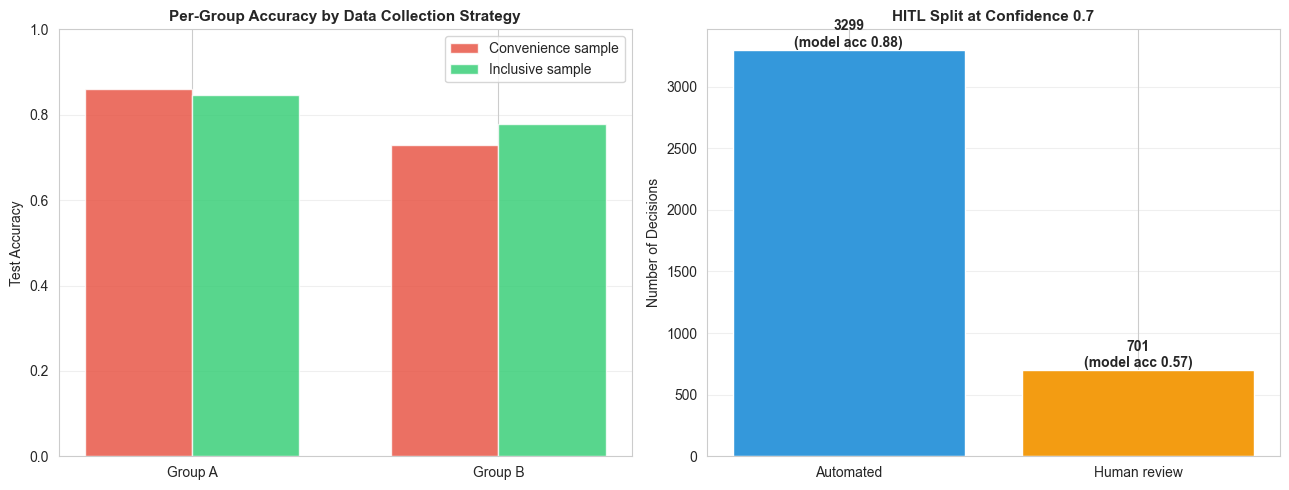

Left: inclusive collection narrows the Group A vs Group B accuracy gap.
Right: uncertain cases (where the model is weakest) go to human review.


In [4]:
# Step 4: Visualize the comparison and the HITL split

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels = ['Group A', 'Group B']
x = np.arange(len(labels)); width = 0.35
axes[0].bar(x - width/2, [acc_conv[g] for g in labels], width,
            label='Convenience sample', color='#e74c3c', alpha=0.8)
axes[0].bar(x + width/2, [acc_incl[g] for g in labels], width,
            label='Inclusive sample', color='#2ecc71', alpha=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_ylabel('Test Accuracy'); axes[0].set_ylim([0, 1])
axes[0].set_title('Per-Group Accuracy by Data Collection Strategy',
                  fontsize=11, fontweight='bold')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

sizes = [auto_mask.sum(), (~auto_mask).sum()]
axes[1].bar(['Automated', 'Human review'], sizes, color=['#3498db', '#f39c12'])
for i, (v, a) in enumerate(zip(sizes, [acc_auto, acc_deferred])):
    axes[1].text(i, v, f'{v}\n(model acc {a:.2f})', ha='center', va='bottom',
                 fontweight='bold')
axes[1].set_ylabel('Number of Decisions')
axes[1].set_title(f'HITL Split at Confidence {THRESHOLD}',
                  fontsize=11, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Left: inclusive collection narrows the Group A vs Group B accuracy gap.")
print("Right: uncertain cases (where the model is weakest) go to human review.")


## Part 4: The Complete Fair AI Development Pipeline - Recap

We executed the full workflow above, one stage per section. This cell consolidates it.

In [5]:
# Step 5: Consolidate the pipeline results we produced above

print("="*80)
print("FAIR AI DEVELOPMENT PIPELINE - WHAT WE RAN IN THIS NOTEBOOK")
print("="*80)
print(f"""
1. DATA COLLECTION   Compared convenience (95/5) vs inclusive (70/30) sampling
                     -> Group B accuracy: {acc_conv['Group B']:.3f} vs {acc_incl['Group B']:.3f}
2. TRAINING          RandomForest per sample; fairness measured with fairlearn
                     -> A-B accuracy gap: {acc_conv['Group A']-acc_conv['Group B']:+.3f} (convenience) vs {acc_incl['Group A']-acc_incl['Group B']:+.3f} (inclusive)
3. HITL REVIEW       Confidence threshold {THRESHOLD} defers {(~auto_mask).mean():.1%} of decisions
                     -> automated-decision accuracy: {acc_auto:.3f}
4. MONITORING        The metrics above are exactly what a production fairness
                     dashboard would track after each retraining
""")
print("Key practice: fairness is designed in at EVERY stage, not patched at the end.")


FAIR AI DEVELOPMENT PIPELINE - WHAT WE RAN IN THIS NOTEBOOK

1. DATA COLLECTION   Compared convenience (95/5) vs inclusive (70/30) sampling
                     -> Group B accuracy: 0.730 vs 0.779
2. TRAINING          RandomForest per sample; fairness measured with fairlearn
                     -> A-B accuracy gap: +0.130 (convenience) vs +0.066 (inclusive)
3. HITL REVIEW       Confidence threshold 0.7 defers 17.5% of decisions
                     -> automated-decision accuracy: 0.877
4. MONITORING        The metrics above are exactly what a production fairness
                     dashboard would track after each retraining

Key practice: fairness is designed in at EVERY stage, not patched at the end.


## 🎯 Summary: What We Learned

**BEFORE this notebook**: We learned to detect and fix bias, but hadn't learned how to build fair systems from the start.

**AFTER this notebook**: We can:
- ✅ Understand inclusive data collection strategies
- ✅ Design bias-aware algorithms
- ✅ Implement human-in-the-loop approaches for fairness
- ✅ Apply best practices for fair AI development
- ✅ Build complete fair AI development workflows
- ✅ Prevent bias from the start (better than fixing later!)

### Key Takeaways

1. **Inclusive Data Collection**: Foundation of fair AI - ensure all groups are represented
2. **Bias-Aware Algorithms**: Incorporate fairness constraints during training
3. **Human-in-the-Loop**: Use human judgment for uncertain cases to improve fairness
4. **Prevention**: Building fair systems from the start is more efficient than fixing later
5. **Complete Workflow**: Fair development requires attention at every stage (data → model → deployment)

---

## ➡️ Transition to Unit 3: Privacy and Security

### What We've Accomplished

We've completed Unit 2: Bias and Justice! We've learned:
- ✅ How to detect bias in AI systems
- ✅ How to mitigate bias using multiple techniques
- ✅ How to ensure fair representation in data
- ✅ How to build fair AI systems from the start

### The Next Challenge: Privacy and Security

**Fairness is important, but it's not the only ethical concern!**

As we build AI systems, we also need to consider:
- **Privacy**: How do we protect user data?
- **Security**: How do we secure AI systems?
- **Data Protection**: How do we comply with regulations like GDPR?

**The Problem**: We've learned about fairness, but **AI systems also raise privacy and security concerns**:
- AI systems collect and process personal data
- AI systems may be vulnerable to attacks
- AI systems must comply with privacy regulations

**This is exactly what we'll learn in Unit 3: Privacy and Security!**

---

## ➡️ Next Steps

**You've completed Unit 2!** Now you understand:
- ✅ How to detect and mitigate bias
- ✅ How to ensure fair representation
- ✅ How to build fair AI systems systematically

**Next Unit**: `unit3-privacy-security/`
- Learn about privacy protection in AI
- Understand security vulnerabilities
- Master GDPR compliance
- Build secure and private AI systems

**Congratulations!** 🎉 You've completed Unit 2 and learned how to build fair AI systems from the ground up!